# Regresion Logística

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from utils import apply_dark_theme
from lr import LogisticRegression

apply_dark_theme()

In [5]:
X, y = make_classification(
    n_samples=2000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    flip_y=0.03,
    random_state=42
)

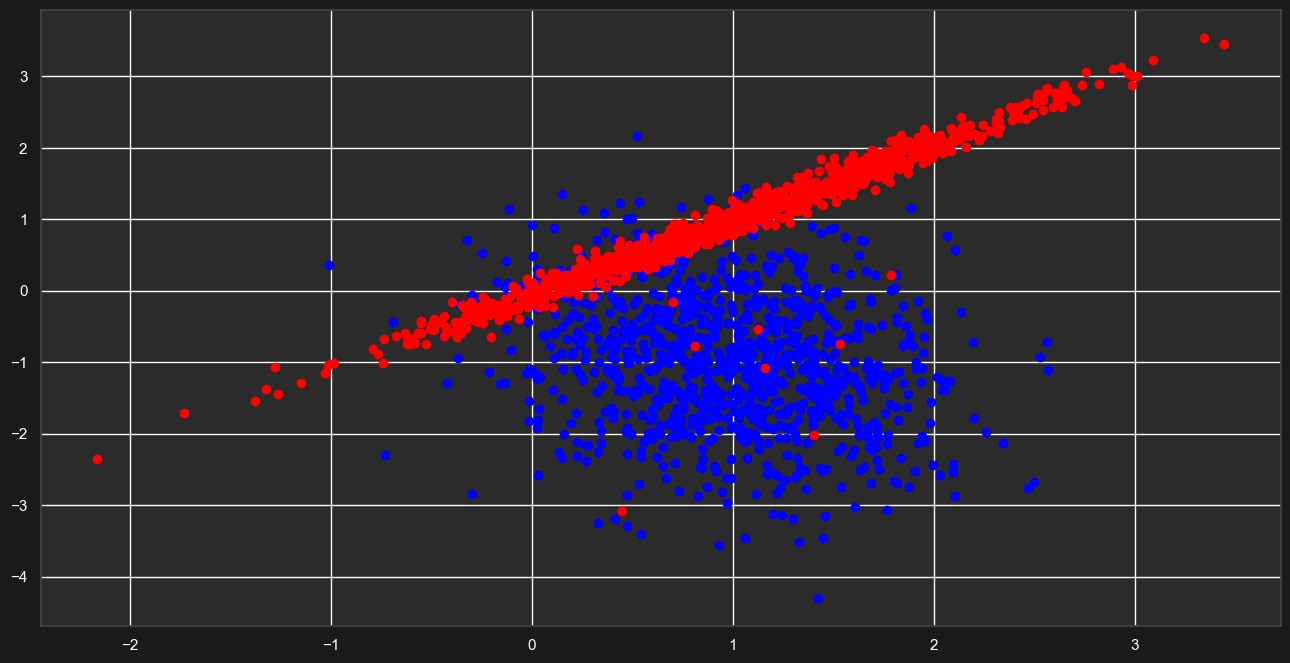

In [6]:
plt.figure(figsize=(16, 8))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='blue')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='red')
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [10]:
modelo = LogisticRegression(learning_rate=0.01, n_iterations=5000)
modelo.fit(X_train, y_train)

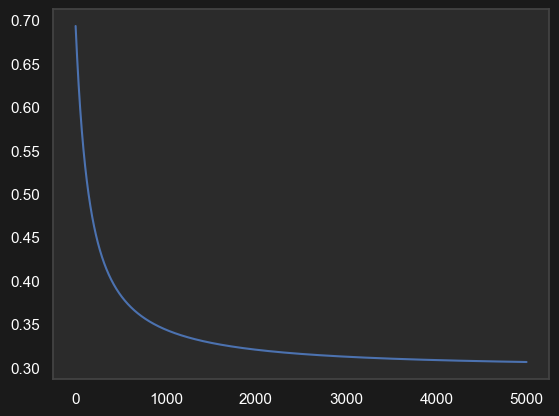

In [11]:
# visualicemos la funcion de costo

plt.plot(modelo.cost_history)
plt.grid()
plt.show()

In [12]:
# clasifiquemos

y_pred = modelo.predict(X_test)
y_pred_proba = modelo.predict_proba(X_test)

In [13]:
# evalemos el desempeñeo del modelo
print('Exactitud: ', accuracy_score(y_test, y_pred))
print('UAC-ROC ', roc_auc_score(y_test, y_pred))
print('Reporte de clasificacion: \n', classification_report(y_test, y_pred))

Exactitud:  0.8716666666666667
UAC-ROC  0.8718810780772437
Reporte de clasificacion: 
               precision    recall  f1-score   support

           0       0.86      0.88      0.87       295
           1       0.89      0.86      0.87       305

    accuracy                           0.87       600
   macro avg       0.87      0.87      0.87       600
weighted avg       0.87      0.87      0.87       600



In [15]:
X_min, X_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1 # este y no es la salida, sino el eje del plot

In [16]:

# creamos la mallla
X_mesh, y_mesh = np.meshgrid(np.arange(X_min, X_max, 0.1), np.arange(y_min, y_max, 0.1))


In [24]:
# predecimos usando la malla

z = modelo.predict(np.c_[X_mesh.ravel(), y_mesh.ravel()])
z = z.reshape(X_mesh.shape)

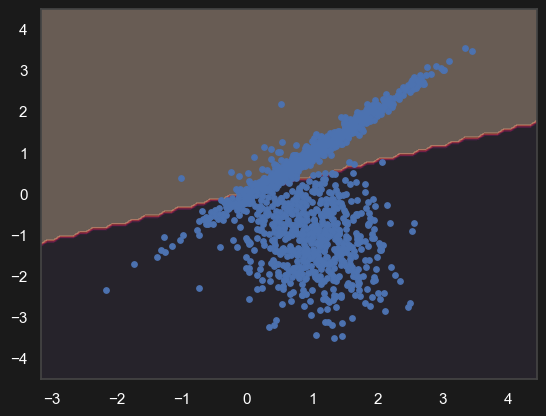

In [27]:
plt.contourf(X_mesh, y_mesh, z, alpha=0.3)
plt.scatter(X_train[:, 0], X_train[:, 1], s=15)
plt.grid()